<div style="display: flex; background-color: RGB(255,114,0);" >
<h1 style="margin: auto; padding: 30px; ">ANALYSE DU STOCK ET DES VENTES DU SITE BOTTLENECK</h1>
</div>

<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 1 - Importation des librairies et chargement des fichiers</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">1.1 - Importation des librairies</h3>
</div>

In [ ]:
#Importation de la librairie Pandas
import pandas as pd
import numpy as np
import plotly.express as px

In [ ]:
#Afficher toutes les colonnes d'un dataframe
pd.set_option('display.max_columns', None) #permet d'afficher toutes les colonnes d'un dataframe sans limitation

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">1.2 - Chargements des fichiers</h3>
</div>

In [ ]:
#Connexion à des sources de données sur Google Drive
#pour pouvoir accéder aux données à partir de différents appareils
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#Importation du fichier web.xlsx
file_path_web = '/content/drive/My Drive/Datasets/web.xlsx'
df_web = pd.read_excel(file_path_web, engine='openpyxl')

#Importation du fichier erp.xlsx
file_path_erp = '/content/drive/My Drive/Datasets/erp.xlsx'
df_erp = pd.read_excel(file_path_erp, engine='openpyxl')

#importation du fichier liaison.xlsx
file_path_liason = '/content/drive/My Drive/Datasets/liaison.xlsx'
df_liaison = pd.read_excel(file_path_liason, engine='openpyxl')

/usr/local/lib/python3.11/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


In [ ]:
#aperçu de dataframe web
df_web.head()

,sku,virtual,downloadable,rating_count,average_rating,total_sales,tax_status,tax_class,post_author,post_date,post_date_gmt,post_content,product_type,post_title,post_excerpt,post_status,comment_status,ping_status,post_password,post_name,post_modified,post_modified_gmt,post_content_filtered,post_parent,guid,menu_order,post_type,post_mime_type,comment_count
0,11862,0,0,0,0.0,3.0,NaN,NaN,2.0,2018-02-12 13:46:23,2018-02-12 12:46:23,NaN,Vin,Gilles Robin Hermitage Rouge 2012,NaN,publish,closed,closed,NaN,gilles-robin-hermitage-2012,2019-01-31 12:12:56,2019-01-31 11:12:56,NaN,0.0,https://www.bottle-neck.fr/wp-content/uploads/...,0.0,attachment,image/jpeg,0.0
1,16057,0,0,0,0.0,5.0,NaN,NaN,2.0,2018-04-17 15:29:17,2018-04-17 13:29:17,NaN,Vin,Domaine Pellé Sancerre Rouge La Croix Au Garde...,NaN,publish,closed,closed,NaN,pelle-sancerre-rouge-la-croix-au-garde-2017,2020-07-07 10:05:02,2020-07-07 08:05:02,NaN,0.0,https://www.bottle-neck.fr/wp-content/uploads/...,0.0,attachment,image/jpeg,0.0
2,14692,0,0,0,0.0,5.0,taxable,NaN,2.0,2019-03-19 10:06:47,2019-03-19 09:06:47,NaN,Vin,Château Fonréaud Bordeaux Blanc Le Cygne 2016,<div>Grâce à la complémentarité des 3 cépages ...,publish,closed,closed,NaN,fonreaud-bordeaux-blanc-le-cygne-2016,2020-04-25 21:40:31,2020-04-25 19:40:31,NaN,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0
3,16295,0,0,0,0.0,14.0,NaN,NaN,2.0,2018-02-15 14:05:06,2018-02-15 13:05:06,NaN,Vin,Moulin de Gassac IGP Pays d'Hérault Guilhem Ro...,NaN,publish,closed,closed,NaN,moulin-de-gassac-igp-pays-dherault-guilhem-ros...,2020-08-27 18:55:03,2020-08-27 16:55:03,NaN,0.0,https://www.bottle-neck.fr/wp-content/uploads/...,0.0,attachment,image/jpeg,0.0
4,15328,0,0,0,0.0,2.0,taxable,NaN,2.0,2019-03-27 18:05:09,2019-03-27 17:05:09,NaN,Vin,Agnès Levet Côte Rôtie Maestria 2017,"<span style=""float: none; background-color: tr...",publish,closed,closed,NaN,agnes-levet-cote-rotie-maestria-2017,2020-07-25 15:45:02,2020-07-25 13:45:02,NaN,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0


In [ ]:
#aperçu de dataframe liason
df_liaison.head()

,id_web,product_id
0,15298,3847
1,15296,3849
2,15300,3850
3,19814,4032
4,19815,4039


<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 2 - Analyse exploratoire des fichiers</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1 - Analyse exploratoire du fichier erp.xlsx</h3>
</div>

In [ ]:
#Afficher les dimensions du dataset
print("Le tableau comporte {} observation(s) ou article(s)".format(df_erp.shape[0])) #df_erp.shape[0] - nombre de lignes
print("Le tableau comporte {} colonne(s)".format(df_erp.shape[1])) #df_erp.shape[1] - nombre de colonnes

Le tableau comporte 825 observation(s) ou article(s)
Le tableau comporte 6 colonne(s)


In [ ]:
#Consulter le nombre de colonnes
print(f"Le tableau comporte {df_erp.shape[1]} colonne(s).") #Cela rend le code plus lisible en utilisant le formatage des f-strings

Le tableau comporte 6 colonne(s).


In [ ]:
#La nature des données dans chacune des colonnes
print("Informations sur le dataset :"); df_erp.info() #L'utilisation de ; permet d'écrire deux expressions sur la même ligne

Informations sur le dataset :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 825 entries, 0 to 824
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   product_id      825 non-null    int64  
 1   onsale_web      825 non-null    int64  
 2   price           825 non-null    float64
 3   stock_quantity  825 non-null    int64  
 4   stock_status    825 non-null    object 
 5   purchase_price  825 non-null    float64
dtypes: float64(2), int64(3), object(1)
memory usage: 38.8+ KB


In [ ]:
#Le nombre de valeurs présentes dans chacune des colonnes
print("Nombre de valeurs présentes dans chaque colonne :")
print(df_erp.count())

Nombre de valeurs présentes dans chaque colonne :
product_id        825
onsale_web        825
price             825
stock_quantity    825
stock_status      825
purchase_price    825
dtype: int64


In [ ]:
#Afficher les 5 premières lignes de la table
df_erp.head()

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price
0,3847,1,24.2,16,instock,12.88
1,3849,1,34.3,10,instock,17.54
2,3850,1,20.8,0,outofstock,10.64
3,4032,1,14.1,26,instock,6.92
4,4039,1,46.0,3,outofstock,23.77


In [ ]:
#Vérifier si il y a les lignes en doublons dans la colonne product_id
print(f"Nombre de doublons dans la colonne 'product_id' : {df_erp['product_id'].duplicated().sum()}")

Nombre de doublons dans la colonne 'product_id' : 0


In [ ]:
#Afficher les valeurs distinctes de la colonne stock_status
print("Valeurs distinctes dans 'stock_status' :")
print(df_erp['stock_status'].unique())

Valeurs distinctes dans 'stock_status' :
['instock' 'outofstock']


In [ ]:
#Création d'une colonne "stock_status_2"
#La valeur de cette deuxième colonne sera fonction de la valeur dans la colonne "stock_quantity"
#si la valeur de la colonne "stock_quantity" est nulle renseigner "outofstock" sinon mettre "instock"

df_erp['stock_status_2'] = np.where(df_erp['stock_quantity'] <= 0, 'outofstock', 'instock') #np.where(condition, value_if_true, value_if_false)
#si la condition (df_erp['stock_quantity'] <= 0) est remplie, « outofstock » est écrit, sinon « instock » est écrit

#vérification des résultats
df_erp[['stock_quantity', 'stock_status_2']].head()

,stock_quantity,stock_status_2
0,16,instock
1,10,instock
2,0,outofstock
3,26,instock
4,3,instock


In [ ]:
#Vérifions que les 2 colonnes sont identiques:
#Les 2 colonnes sont strictement identiques si les valeurs de chaque ligne sont strictement identiques 2 à 2
#La comparaison de 2 colonnes peut se réaliser simplement avec l'instruction ci-dessous:
df_erp["stock_status"] == df_erp["stock_status_2"]

#Le résultat est l'affichage de True ou False pour chacune des lignes du dataset
#C'est un bon début, mais difficile à exploiter

,0
0,True
1,True
2,True
3,True
4,False
...,...
820,True
821,True
822,True
823,True


Pourquoi est-il difficile d'utiliser ce résultat directement ?
Le résultat est une liste booléenne (Vrai / Faux) pour chaque ligne, mais il est difficile de l'analyser manuellement si le tableau comporte de nombreuses lignes. Pour faciliter l'analyse, on peut:

*   Compter le nombre total de lignes où les valeurs correspondent/ne correspondent pas
*   Afficher uniquement les lignes où les valeurs ne correspondent pas



In [ ]:
#Mais il est possible de synthétiser ce résultat en effectuant la somme de cette colonne:
#True vaut 1 et False 0
#Nous devrions obtenir la somme de 825 qui correspond au nombre de lignes dans ce dataset

(df_erp["stock_status"] == df_erp["stock_status_2"]).sum()

823

In [ ]:
#vérification des données après modification
#filtrage des lignes qui présentent des différences
differences = df_erp[df_erp["stock_status"] != df_erp["stock_status_2"]]

#afficher les lignes qui ont des différences
print("Lignes avec des écarts :")
print(differences[['product_id', 'stock_quantity', 'stock_status', 'stock_status_2']])

Lignes avec des écarts :
     product_id  stock_quantity stock_status stock_status_2
4          4039               3   outofstock        instock
398        4885               0      instock     outofstock


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1 - Analyse exploratoire de chaque variable du fichier erp.xlsx</h3>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.1 - Analyse de la variable PRIX</h3>
</div>

In [ ]:
###############
## LES PRIX  ##
###############

#Vérification des prix: Y a t-il des prix non renseignés, négatif ou nul?

#Afficher le ou les prix non renseignés dans la colonne "price"
print("Nombres d'article avec un prix non renseignés: {}".format(df_erp['price'].isnull().sum()))

#Afficher le prix minimum de la colonne "price"
print("Le prix minimum dans la colonne 'price' est : {}".format(df_erp['price'].min()))

#Afficher le prix maximum de la colonne "price"
print("Le prix minimum dans la colonne 'price' est : {}".format(df_erp['price'].max()))

#Affichier les prix inférieurs à 0 (qu'est ce qu'il faut en faire ?)
negative_prices = df_erp[df_erp['price'] < 0]
print(f"Lignes avec des prix inférieurs à 0 : {negative_prices}")


Nombres d'article avec un prix non renseignés: 0
Le prix minimum dans la colonne 'price' est : -20.0
Le prix minimum dans la colonne 'price' est : 225.0
Lignes avec des prix inférieurs à 0 :      product_id  onsale_web  price  stock_quantity stock_status  \
151        4233           0  -20.0               0   outofstock   
469        5017           0   -8.0               0   outofstock   
739        6594           0   -9.1              19      instock   

     purchase_price stock_status_2  
151           10.33     outofstock  
469            4.34     outofstock  
739            4.61        instock  


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.2 - Analyse de la variable STOCK</h3>
</div>

In [ ]:
#######################
### stock_quantity  ###
#######################

#Vérification de la colonne stock quantity
#Afficher la quantité minimum de la colonne "stock_quantity"
print("La quantité minimum dans la colonne 'stock_quantity' est : {}".format(df_erp['stock_quantity'].min()))

#Afficher la quantité maximum de la colonne "stock_quantity"
print("La quantité minimum dans la colonne 'stock_quantity' est : {}".format(df_erp['stock_quantity'].max()))

#Affichier les stocks inférieurs à 0 (qu'est ce qu'il faut en faire ?)
negative_stocks = df_erp[df_erp['stock_quantity'] < 0]
print("Lignes avec des stocks inférieurs à 0 :")
print(negative_stocks)

La quantité minimum dans la colonne 'stock_quantity' est : -10
La quantité minimum dans la colonne 'stock_quantity' est : 145
Lignes avec des stocks inférieurs à 0 :
     product_id  onsale_web  price  stock_quantity stock_status  \
449        4973           0   10.0             -10   outofstock   
573        5700           1   44.5              -1   outofstock   

     purchase_price stock_status_2  
449            4.96     outofstock  
573           22.30     outofstock  


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.3 - Analyse de la variable ONSALE_WEB</h3>
</div>

In [ ]:
#Vérification de la colonne onsale_web et des valeurs qu'elle contient? Que signifient-elles?

# Valeurs uniques et leur fréquence
# 1: Le produit est en vente sur le site web
# 0: L'article n'est pas mis en vente sur le site web
print("Valeurs uniques dans la colonne 'onsale_web' :")
print(df_erp['onsale_web'].value_counts())

Valeurs uniques dans la colonne 'onsale_web' :
onsale_web
1    716
0    109
Name: count, dtype: int64


In [ ]:
# Rechercher les valeurs manquantes
missing_onsale_web = df_erp['onsale_web'].isnull().sum()
print(f"Nombre de valeurs manquantes dans 'onsale_web' : {missing_onsale_web}")

Nombre de valeurs manquantes dans 'onsale_web' : 0


In [ ]:
#Quelles sont les colonnes à conserver selon vous?
#Supprimer la colonne comportant le libellé "stock_status_2" car elle est redondante
colonnes_a_conserver = ['product_id', 'price', 'stock_quantity', 'stock_status', 'onsale_web', 'purchase_price']

# Sauvegarder uniquement les colonnes nécessaires
df_erp = df_erp[colonnes_a_conserver]

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.4 - Analyse de la variable prix d'achat</h3>
</div>

In [ ]:
######################
##   prix d'achat   ##
######################

#Vérification de la colonne purchase_price :
#Afficher le ou les prix non renseignés dans la colonne "purchase_price"
print(f"Nombre de lignes avec un prix non renseigné dans 'purchase_price' : {df_erp['purchase_price'].isnull().sum()}")

#Afficher les lignes avec des valeurs manquantes
#missing_purchase_price = df_erp[df_erp['purchase_price'].isnull()]
#print("Lignes avec un prix non renseigné dans 'purchase_price' :")
#print(missing_purchase_price)

#Afficher le prix minimum de la colonne "purchase_price"
print("Le prix minimum dans la colonne 'purchase_price' est : {}".format(df_erp['purchase_price'].min()))

#Afficher le prix maximum de la colonne "purchase_price"
print("Le prix minimum dans la colonne 'purchase_price' est : {}".format(df_erp['purchase_price'].max()))

Nombre de lignes avec un prix non renseigné dans 'purchase_price' : 0
Le prix minimum dans la colonne 'purchase_price' est : 2.74
Le prix minimum dans la colonne 'purchase_price' est : 137.81


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.2 - Analyse exploratoire du fichier web.xlsx</h3>
</div>


In [ ]:
#Dimension du dataset
print(f"Dimensions du dataset : {df_web.shape}")

#Nombre d'observations
print(f"Nombre d'observations (lignes) : {df_web.shape[0]}")

#Nombre de caractéristiques
print(f"Nombre de caractéristiques (colonnes) : {df_web.shape[1]}")

Dimensions du dataset : (1513, 29)
Nombre d'observations (lignes) : 1513
Nombre de caractéristiques (colonnes) : 29


In [ ]:
#La nature des données dans chacune des colonnes
print("Nature des données dans chaque colonne :")
print(df_web.dtypes)

#Le nombre de valeurs présentes dans chacune des colonnes
print("Nombre de valeurs présentes dans chaque colonne :")
print(df_web.count())

Nature des données dans chaque colonne :
sku                              object
virtual                           int64
downloadable                      int64
rating_count                      int64
average_rating                  float64
total_sales                     float64
tax_status                       object
tax_class                       float64
post_author                     float64
post_date                datetime64[ns]
post_date_gmt            datetime64[ns]
post_content                    float64
product_type                     object
post_title                       object
post_excerpt                     object
post_status                      object
comment_status                   object
ping_status                      object
post_password                   float64
post_name                        object
post_modified            datetime64[ns]
post_modified_gmt        datetime64[ns]
post_content_filtered           float64
post_parent                     float64

In [ ]:
#Si vous avez défini des colonnes à supprimer, effectuer l'opération
df_web.drop(columns=['tax_class', 'post_content', 'post_password', 'post_content_filtered'], inplace=True)
print(df_web.count())

sku                  1428
virtual              1513
downloadable         1513
rating_count         1513
average_rating       1430
total_sales          1430
tax_status            716
post_author          1430
post_date            1430
post_date_gmt        1430
product_type         1429
post_title           1430
post_excerpt          716
post_status          1430
comment_status       1430
ping_status          1430
post_name            1430
post_modified        1430
post_modified_gmt    1430
post_parent          1430
guid                 1430
menu_order           1430
post_type            1430
post_mime_type        714
comment_count        1430
dtype: int64


In [ ]:
#Visualisation des valeurs de la colonne sku
#Afficher les valeurs uniques et leur fréquence
print("Valeurs uniques dans la colonne 'sku' :")
print(df_web['sku'].value_counts())

Valeurs uniques dans la colonne 'sku' :
sku
11862    2
16324    2
3507     2
14773    2
15967    2
        ..
12639    2
15466    2
15184    2
13078    2
14569    2
Name: count, Length: 714, dtype: int64


In [ ]:
#SUPPRIMER LES DOUBLONS DANS LA COLONNE SKU

#Filtrer les lignes où post_type n'est pas "attachment"
df_web = df_web[df_web['post_type'] != "attachment"]

#Réinitialiser l'index après le filtrage
#pour mettre à jour les numéros de ligne après la suppression des données !!!
df_web = df_web.reset_index(drop=True)

#Vérifier les valeurs uniques restantes dans post_type
print("Valeurs uniques dans 'post_type' après filtrage :", df_web['post_type'].unique())

#Vérifier la nouvelle dimension du dataset
print(f"Dimensions du dataset après filtrage : {df_web.shape}")


Valeurs uniques dans 'post_type' après filtrage : ['product' nan]
Dimensions du dataset après filtrage : (799, 25)


In [ ]:
#VÉRIFIER LES DOUBLONS DANS LA COLONNE SKU
nb_duplicated_sku = df_web['sku'].duplicated().sum()
print(f"Nombre de valeurs en doublon dans 'sku' : {nb_duplicated_sku}")

if nb_duplicated_sku > 0:
   print(df_web[df_web['sku'].duplicated(keep=False)].sort_values(by='sku').head(10))
#Si vous avez identifié des codes articles ne respectant pas la régle de codification, consultez-les?

Nombre de valeurs en doublon dans 'sku' : 84
    sku  virtual  downloadable  rating_count  average_rating  total_sales  \
3   NaN        0             0             0             NaN          NaN   
9   NaN        0             0             0             NaN          NaN   
15  NaN        0             0             0             NaN          NaN   
19  NaN        0             0             0             NaN          NaN   
20  NaN        0             0             0             NaN          NaN   
24  NaN        0             0             0             NaN          NaN   
27  NaN        0             0             0             NaN          NaN   
39  NaN        0             0             0             NaN          NaN   
49  NaN        0             0             0             NaN          NaN   
66  NaN        0             0             0             NaN          NaN   

   tax_status  post_author post_date post_date_gmt product_type post_title  \
3         NaN          NaN   

In [ ]:
# Supprimer les lignes contenant NaN dans sku
df_web = df_web.dropna(subset=['sku'])
print(f"Nombre de lignes après suppression des NaN dans 'sku' : {df_web.shape[0]}")

# Revérifier la colonne pour détecter les doublons
nb_duplicated_sku = df_web['sku'].duplicated().sum()
print(f"Nombre de doublons dans 'sku' : {nb_duplicated_sku}")

Nombre de lignes après suppression des NaN dans 'sku' : 714
Nombre de doublons dans 'sku' : 0


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.3 - Analyse exploratoire du fichier liaison.xlsx</h3>
</div>

In [ ]:
#Dimension du dataset
print(f"Dimensions du dataset : {df_liaison.shape}")

#Nombre d'observations
print(f"Nombre d'observations (lignes) : {df_liaison.shape[0]}")

#Nombre de caractéristiques
print(f"Nombre de caractéristiques (colonnes) : {df_liaison.shape[1]}")

Dimensions du dataset : (825, 2)
Nombre d'observations (lignes) : 825
Nombre de caractéristiques (colonnes) : 2


In [ ]:
#La nature des données dans chacune des colonnes
print("Nature des données dans chaque colonne :")
print(df_liaison.dtypes)

#Le nombre de valeurs présentes dans chacune des colonnes
print("\nNombre de valeurs présentes dans chaque colonne :")
print(df_liaison.count())

Nature des données dans chaque colonne :
id_web        object
product_id     int64
dtype: object

Nombre de valeurs présentes dans chaque colonne :
id_web        734
product_id    825
dtype: int64


In [ ]:
#Les valeurs de la colonne "product_id" sont elles toutes uniques?

nb_duplicated_product_id = df_liaison['product_id'].duplicated().sum()
print(f"Nombre de doublons dans 'product_id' : {nb_duplicated_product_id}")

Nombre de doublons dans 'product_id' : 0


In [ ]:
#Les valeurs de la colonne "id_web" sont-elles toutes uniques?

nb_duplicated_id_web = df_liaison['id_web'].duplicated().sum()
print(f"Nombre de doublons dans 'id_web' : {nb_duplicated_id_web}")

# Vérifier les valeurs NaN
nb_nan = df_liaison['id_web'].isna().sum()
print(f"Nombre de valeurs NaN dans 'id_web' : {nb_nan}")

Nombre de doublons dans 'id_web' : 90
Nombre de valeurs NaN dans 'id_web' : 91


In [ ]:
print(df_liaison[df_liaison['id_web'].isna()])

    id_web  product_id
19     NaN        4055
49     NaN        4090
50     NaN        4092
119    NaN        4195
131    NaN        4209
..     ...         ...
817    NaN        7196
818    NaN        7200
819    NaN        7201
820    NaN        7203
821    NaN        7204

[91 rows x 2 columns]


In [ ]:
#Vérifier s'il y a 'product_id' dans les lignes NaN de df_erp
missing_web_products = df_erp[df_erp['product_id'].isin(df_liaison[df_liaison['id_web'].isna()]['product_id'])]

print(f"Nombre de produits sans id_web mais présents dans erp.xlsx : {missing_web_products.shape[0]}")
print(missing_web_products.head())


Nombre de produits sans id_web mais présents dans erp.xlsx : 91
     product_id  price  stock_quantity stock_status  onsale_web  \
19         4055   86.1               0   outofstock           0   
49         4090   73.0               0   outofstock           0   
50         4092   47.0               0   outofstock           0   
119        4195   14.1               0   outofstock           0   
131        4209   73.5               0   outofstock           0   

     purchase_price  
19            37.88  
49            33.79  
50            25.25  
119            7.36  
131           33.01  


In [ ]:
#Remplacer NaN dans 'id_web' par 'Non-dispo-web' pour les éléments présents dans erp.xlsx mais absents dans web.xlsx
df_liaison['id_web'] = df_liaison['id_web'].fillna("Non-dispo-web")
print(f"Nombre de valeurs NaN dans 'id_web' après remplacement : {df_liaison['id_web'].isna().sum()}")

Nombre de valeurs NaN dans 'id_web' après remplacement : 0


In [ ]:
#Trouver les valeurs dupliquées et leur fréquence
duplicated_values = df_liaison['id_web'].value_counts()
duplicated_values = duplicated_values[duplicated_values > 1]  # Filtrer uniquement les doublons

#Afficher les résultats
print("Valeurs dupliquées dans 'id_web' et leur fréquence :")
print(duplicated_values)


Valeurs dupliquées dans 'id_web' et leur fréquence :
id_web
Non-dispo-web    91
Name: count, dtype: int64


In [ ]:
#Avons-nous des articles sans correspondances?

#Vérifier s'il y a des product_id dans liaison.xlsx qui ne sont pas dans erp.xlsx
articles_sans_correspondance_erp = df_liaison[~df_liaison['product_id'].isin(df_erp['product_id'])]

#Vérifier s'il y a des id_web dans liaison.xlsx qui ne sont pas dans web.xlsx
articles_sans_correspondance_web = df_liaison[~df_liaison['id_web'].isin(df_web['sku'])]

#Sortie du nombre d'articles non conformes
print(f"Nombre d'articles sans correspondance dans 'erp.xlsx' : {articles_sans_correspondance_erp.shape[0]}")
print(f"Nombre d'articles sans correspondance dans 'web.xlsx' : {articles_sans_correspondance_web.shape[0]}")

Nombre d'articles sans correspondance dans 'erp.xlsx' : 0
Nombre d'articles sans correspondance dans 'web.xlsx' : 111


In [ ]:
#Voir les valeurs non concordants sauf les valeurs "non-dispo-web"
filtered_data = articles_sans_correspondance_web[articles_sans_correspondance_web['id_web'] != "non-dispo-web"]
print(filtered_data)

            id_web  product_id
19   Non-dispo-web        4055
49   Non-dispo-web        4090
50   Non-dispo-web        4092
119  Non-dispo-web        4195
131  Non-dispo-web        4209
..             ...         ...
818  Non-dispo-web        7200
819  Non-dispo-web        7201
820  Non-dispo-web        7203
821  Non-dispo-web        7204
823        14680-1        7329

[111 rows x 2 columns]


<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 3 - Jonction des fichiers</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 3.1 - Jonction du fichier df_erp et df_liaison</h3>
</div>

In [ ]:
#Fusion des fichiers df_erp et df_liaison

# Fusionner df_erp et df_liaison par la clé 'product_id'
df_merge = df_liaison.merge(df_erp, on='product_id', how='left', indicator=True)

# Vérifier le résultat de la fusion
print(f"Nombre total de lignes après fusion : {df_merge.shape[0]}")
print("\nAperçu du dataset fusionné (ERP + LIASON) :"); print(df_merge.head())

Nombre total de lignes après fusion : 825

Aperçu du dataset fusionné (ERP + LIASON) :
  id_web  product_id  price  stock_quantity stock_status  onsale_web  \
0  15298        3847   24.2              16      instock           1   
1  15296        3849   34.3              10      instock           1   
2  15300        3850   20.8               0   outofstock           1   
3  19814        4032   14.1              26      instock           1   
4  19815        4039   46.0               3   outofstock           1   

   purchase_price _merge  
0           12.88   both  
1           17.54   both  
2           10.64   both  
3            6.92   both  
4           23.77   both  


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 3.2 - Jonction du fichier df_merge et df_web</h3>
</div>

In [ ]:
#Fusionnez les datasets df_merge et df_web

# Fusionner df_merge (liaison + erp) avec df_web par la clé 'id_web' = 'sku'
df_final = df_merge.merge(df_web, left_on='id_web', right_on='sku', how='left')

# Vérifier le résultat de la fusion
print(f"Nombre total de lignes après fusion : {df_final.shape[0]}")
print("\nAperçu du dataset fusionné (ERP + Liaison + Web) :"); print(df_final.head())

Nombre total de lignes après fusion : 825

Aperçu du dataset fusionné (ERP + Liaison + Web) :
  id_web  product_id  price  stock_quantity stock_status  onsale_web  \
0  15298        3847   24.2              16      instock           1   
1  15296        3849   34.3              10      instock           1   
2  15300        3850   20.8               0   outofstock           1   
3  19814        4032   14.1              26      instock           1   
4  19815        4039   46.0               3   outofstock           1   

   purchase_price _merge    sku  virtual  downloadable  rating_count  \
0           12.88   both  15298      0.0           0.0           0.0   
1           17.54   both  15296      0.0           0.0           0.0   
2           10.64   both  15300      0.0           0.0           0.0   
3            6.92   both  19814      0.0           0.0           0.0   
4           23.77   both  19815      0.0           0.0           0.0   

   average_rating  total_sales tax_statu

In [ ]:
#Avons-nous des lignes sans correspondances?

# Vérifier s'il y a des lignes sans correspondance
articles_sans_correspondance_web = df_merge[~df_merge['id_web'].isin(df_web['sku'])]
print(f"\nNombre d'articles sans correspondance après fusion avec Web : {articles_sans_correspondance_web.shape[0]}")

# Afficher les lignes sans correspondance, le cas échéant
if articles_sans_correspondance_web.shape[0] > 0:
    print("\nArticles sans correspondance dans Web :")
    print(articles_sans_correspondance_web.head())


Nombre d'articles sans correspondance après fusion avec Web : 111

Articles sans correspondance dans Web :
            id_web  product_id  price  stock_quantity stock_status  \
19   Non-dispo-web        4055   86.1               0   outofstock   
49   Non-dispo-web        4090   73.0               0   outofstock   
50   Non-dispo-web        4092   47.0               0   outofstock   
119  Non-dispo-web        4195   14.1               0   outofstock   
131  Non-dispo-web        4209   73.5               0   outofstock   

     onsale_web  purchase_price _merge  
19            0           37.88   both  
49            0           33.79   both  
50            0           25.25   both  
119           0            7.36   both  
131           0           33.01   both  


<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 4 - Analyse univarié des prix</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.1 - Exploration par la visualisation de données</h3>
</div>

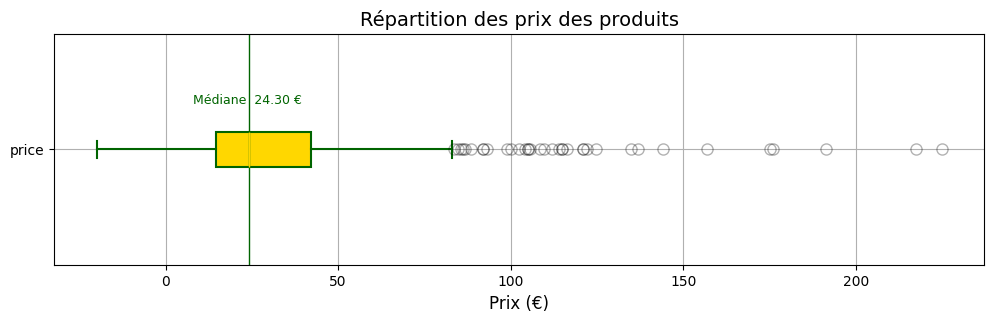

In [ ]:
#Création d'une Boite à moustache de la répartition des prix
import matplotlib.pyplot as plt

#Définir la taille de la graphique
plt.figure(figsize=(12, 3))

#Créer un diagramme boîte à moustaches et configurer les détails de la visualisation
boxplot = df_final.boxplot(column=['price'], #Spécifier la colonne « prix » à analyser
                           vert=False, #Rendre le graphique horizontal (plus visible pour l'analyse)
                           patch_artist=True, #Permettre de changer la couleur de la "boîte"
                           #Configurer la boîte
                           boxprops=dict(facecolor="Gold", color="DarkGreen", linewidth=1.5), #Définir la couleur de la boîte bleue, la bordure bleu, l'épaisseur de la bordure
                           whiskerprops=dict(color="DarkGreen", linewidth=1.5), #Configurer les moustaches - lignes qui montrent une plage de données sans valeurs aberrantes
                           capprops=dict(color="DarkGreen", linewidth=1.5), #Configurer les caps - petites lignes horizontales à la fin des moustaches
                           medianprops=dict(color="Gold"), #Configurer la ligne médiane au centre de la boîte
                           flierprops=dict(marker='o', color='DarkGreen', markersize=8, alpha=0.3)) #Configurer les fliers - points situés à l'extérieur des moustaches

#Définir la ligne médiane et afficher la valeur
median = df_final['price'].median()  #Calculer la médiane
plt.axvline(median, color='DarkGreen', linestyle='-', linewidth=1, label=f'Médiane ({median:.2f} €)')

#Configurer le texte de la valeur médiane
plt.text(median - 0.5, 1.2, f'Médiane  {median:.2f} €', color='DarkGreen', fontsize=9, ha='center')

# Définir l'en-tête du graphique et la taille de la police
plt.title("Répartition des prix des produits", fontsize=14)

# Définir la légende de l'axe des X et la taille de la police
plt.xlabel("Prix (€)", fontsize=12)

# Afficher le graphique
plt.show()

In [ ]:
#Autre méthode avec plotly express
#Importer la bibliothèque Plotly Express pour créer des graphiques interactifs
import plotly.express as px

#Créer un boxplot avec Plotly Express
fig = px.box(df_final, #Utiliser un dataframe fusionné avec les prix des produits
             x='price', #Analyser la distribution de la variable « prix » (axe des X)
             title="Répartition des prix des produits",  #Définir le titre du graphique
             points="all", #Afficher toutes les valeurs aberrantes (tous les points en dehors de la moustache)
             color_discrete_sequence=["DarkGreen"])  #Définir la couleur de la « boîte »

#Personnaliser l'apparence du graphique
fig.update_layout(
    xaxis_title="Prix (€)",  #Ajouter la légende de l'axe X (prix en euros)
    title_x=0.5, #Centrer l'en-tête sur l'axe X
    width=1200, #Définir la largeur du graphique (1200 pixels)
    height=500, #Définir la hauteur du graphique (500 pixels)
    template='plotly_white'  #Style visuel du graphique
    )

#Afficher le graphique
fig.show()

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.2 - Exploration par l'utisation de méthodes statistique</h3>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.2.1 - Identification par le Z-index</h3>
</div>

**écart-type** - la dispersion des prix par rapport à la moyenne

**Z-score** - montre de combien d'écarts types le prix dévie de la moyenne

In [ ]:
#Calculer la moyenne du prix
mean_price = df_final['price'].mean()  #Calculer la moyenne de la colonne « prix »
print(f"Moyenne du prix : {mean_price:.2f} €")  #Afficher la moyenne, utiliser :.2f pour arrondir le résultat à deux décimales

#Calculer l'écart-type du prix (std()), qui indique la dispersion des prix par rapport à la moyenne
std_price = df_final['price'].std()  #Calculer l'écart-type pour la colonne « prix »
print(f"Écart-type du prix : {std_price:.2f} €")  #Afficher le résultat et l'arrondir à 2 décimales

#Calculer le Z-score - cet indicateur montre de combien d'écarts types le prix dévie de la moyenne
df_final['z_score'] = (df_final['price'] - mean_price) / std_price  #Appliquer la formule du Z-score

#Afficher un aperçu des prix avec leurs Z-scores - afficher les premières 20 lignes du Z-score
print("\nAperçu des prix avec leurs Z-scores :")
print(df_final[['price', 'z_score']].head(20))  #Afficher uniquement les colonnes « prix » et « z_score » pour l'analyse


Moyenne du prix : 32.19 €
Écart-type du prix : 26.71 €

Aperçu des prix avec leurs Z-scores :
    price   z_score
0    24.2 -0.299029
1    34.3  0.079077
2    20.8 -0.426313
3    14.1 -0.677136
4    46.0  0.517081
5    34.3  0.079077
6    32.7  0.019179
7    31.2 -0.036976
8    60.0  1.041188
9    42.6  0.389798
10   80.0  1.789913
11   18.3 -0.519903
12   22.8 -0.351440
13   19.3 -0.482467
14   21.8 -0.388876
15    7.7 -0.916728
16   33.7  0.056615
17   44.3  0.453439
18   71.6  1.475449
19   86.1  2.018274


### Explication intermédiaire du résultat :

**Prix moyen = 32,25 €,** cela signifie qu'en moyenne les produits coûtent 32,25 €.

**L'écart-type = 27,13 €,** ce qui signifie que l'écart de prix par rapport à la moyenne est assez élevé. Cela signifie également qu'il y a des produits avec des prix très différents dans le catalogue.

Tous les éléments présentés ont un Z-score compris **entre -1 et 1,** ce qui est normal.

Les vraies anomalies sont celles dont le Z-score est **> 3 ou le score Z < -3**.





In [ ]:
#Quel est le seuil prix dont z-score est supérieur à 3? Si le Z-score est > 3, il s'agit d'une valeur aberrante

#Déterminer le seuil de prix où le Z-score dépasse 3

#Prendre le prix minimal parmi tous ceux dont le z_score est > 3 (min())
#Il s'agit du prix seuil à partir duquel les prix sont considérés comme des valeurs aberrantes
seuil_prix = df_final[df_final['z_score'] > 3]['price'].min()

#Afficher le résultat et utiliser :.2f pour arrondir le prix à deux décimales
print(f"Seuil du prix avec un Z-score supérieur à 3 : {seuil_prix:.2f} €")

Seuil du prix avec un Z-score supérieur à 3 : 114.00 €


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.2.2 - Identification par l'interval interquartile</h3>
</div>

In [ ]:
#Utilisation de la fonction describe de Pandas pour l'etude des mesures de dispersions
#pour analyser les caractéristiques statistiques des prix
stat_desc = df_final['price'].describe()

#Afficher les principaux indicateurs statistiques
print("Analyse des mesures de dispersion pour les prix :\n"); print(stat_desc)

#describe() calcule les caractéristiques statistiques de base de la colonne des prix :

# count → nombre d'observations (nombre de produits)
# mean → valeur moyenne
# std → l'écart-type (écart de prix)
# min → prix minima
# 25% → 1er quartile (Q1) - 25 % des valeurs sont inférieures à ce chiffre
# 50% → la médiane (Q2) est le milieu de la distribution
# 75% → 3e quartile (Q3) - 75 % des valeurs sont inférieures à ce chiffre
# max → prix maximal
# print(stat_desc) affiche toutes les statistiques calculées 👇

Analyse des mesures de dispersion pour les prix :

count    825.000000
mean      32.187697
std       26.712077
min      -20.000000
25%       14.500000
50%       24.300000
75%       42.000000
max      225.000000
Name: price, dtype: float64


### 📌 Analyse des caractéristiques statistiques des prix :

✅ count = 825, c'est le nombre d'observations, nous avons donc 825 produits avec le prix spécifié.

✅ mean = 32.18, c'est le prix moyen, cela signifie qu'en moyenne le prix d'un produit est de ≈ 32,18€.

✅ std = 26.71, c'est l'écart-type, qui indique le degré de dispersion des prix par rapport à la moyenne. Une valeur de 26,71 signifie que les prix sont très variables.

✅ min = -20.00 ❗, c'est le prix minimum d'un article. Il s'agit d'une anomalie car les prix ne peuvent pas être négatifs.

✅ 25% = 14.50, Q1, cela signifie que 25 % des produits coûtent moins de 14,30 €. Il s'agit de la partie inférieure de la fourchette de prix moyenne.

✅ 50% = 24.30, médiane, cela signifie que 50 % des produits ont un prix inférieur à 24 € et 50 % ont un prix supérieur. Il s'agit d'un élément central de la distribution des prix.

✅ 75% = 42.00, Q3, ce qui signifie que 75 % des produits coûtent moins de 42 €. C'est le haut de la fourchette des prix moyens.

✅ max = 225.00, l'article le plus cher coûte 225 €.

### 📌  Conclusions et prochaines étapes

✅ Les prix sont en moyenne de ≈ 32.18€, mais varient beaucoup (std = 26.71)

✅ Valeur minimale (-20€) - erreur de données ! Doit être corrigée.

✅ La valeur maximale (225 €) est une valeur aberrante potentielle, qui mérite d'être vérifiée.

In [ ]:
#Définissez un seuil pour les articles "outliers" en prix

#Calculer Q1 et Q3
Q1 = df_final['price'].quantile(0.25)  # 25e percentile (premier quartile) = 14.30€
Q3 = df_final['price'].quantile(0.75)  #  75ème percentile (troisième quartile) = 42.00€

#Calculer l'IQR - la différence entre le troisième (Q3) et le premier (Q1) quartile
IQR = Q3 - Q1

#Définir les seuils bas et haut pour identifier les outliers
seuil_bas = Q1 - 1.5 * IQR
seuil_haut = Q3 + 1.5 * IQR

#Afficher les résultats
print(f"Seuil bas pour détecter les outliers : {seuil_bas:.2f} €")
print(f"Seuil haut pour détecter les outliers : {seuil_haut:.2f} €")

Seuil bas pour détecter les outliers : -26.75 €
Seuil haut pour détecter les outliers : 83.25 €


**IQR (Interquartile Range)** est la différence entre le troisième (Q3) et le premier (Q1) quartile ( IQR=Q3-Q1 ) et indique la dispersion des 50 % des données du milieu (entre 25 % et 75 % des valeurs) et est utilisé pour repérer les valeurs aberrantes:

✅  Valeurs inférieures à Q1 - 1,5 * IQR - très faibles valeurs aberrantes.

✅   Valeurs supérieures à Q3 + 1,5 * IQR sont des valeurs aberrantes très élevées.

L'IQR permet donc de détecter les anomalies et de nettoyer les données.

**Comment cela se traduit-il ?**

✅  Tous les prix inférieurs à seuil_bas ou supérieurs à seuil_haut sont considérés comme aberrants.

✅  Seuil_bas peut être négatif, ce qui indique des erreurs dans les données (par exemple -20€).

✅  Seuil_haut indique quels biens peuvent être trop chers par rapport à d'autres.

In [ ]:
#Définissez le nombre d'articles et la proportion de l'ensemble du catalogue "outliers"

#Identifier les articles / produits considérés comme des outliers
#Créer un dataframe avec soit des prix trop bas (erreurs), soit des prix trop élevés (biens chers)
outliers = df_final[(df_final['price'] < seuil_bas) | (df_final['price'] > seuil_haut)]

#Calculer le nombre total d'articles considérés comme des outliers
#Calculer le nombre de lignes dans un cadre de données qui ne contient que des anomalies
nombre_outliers = outliers.shape[0]

#Calculer la proportion des outliers par rapport à l'ensemble du catalogue (pourcentage des anomalies)
proportion_outliers = (nombre_outliers / df_final.shape[0]) * 100

#Afficher les résultats
print(f"Nombre d'articles considérés comme outliers : {nombre_outliers}")
print(f"Proportion des outliers dans le catalogue : {proportion_outliers:.2f} %") #Arrondir à deux décimales

Nombre d'articles considérés comme outliers : 36
Proportion des outliers dans le catalogue : 4.36 %


### 📌 Question à laquelle il faut répondre :

combien d'articles sont classés comme aberrants ? Quel est le pourcentage de valeurs aberrantes dans le catalogue total ? S'il y a trop de valeurs aberrantes (>10%), nous devons décider si les limites doivent être ajustées. Cela signifie que dans notre cas, le nombre d'écarts est tout à fait acceptable.

### 📌 Comment le montrer ?


✅  `Vérifier la distribution des prix (par histogramme des prix).` Si la distribution des prix montre une baisse douce de la fréquence des produits coûteux, il se peut que les produits coûteux "aberrants" soient réels. Si le graphique montre un déclin naturel, les produits coûteux ne sont pas des valeurs aberrantes, mais des produits haut de gamme. S'il existe un écart de prix, les valeurs aberrantes peuvent être des erreurs.

✅  `Vérifiez les catégories de produits (par analyse par catégorie).` Si des produits coûteux appartiennent à une catégorie supérieure (par exemple, les vins de collection), ils ne peuvent pas être considérés comme des valeurs aberrantes. En revanche, si les émissions sont réparties de manière aléatoire entre des produits ordinaires, il s'agit d'erreurs.

✅  `Comparer avec des données externes (prix du marché).` Il est possible de vérifier si les prix des écarts correspondent aux données du marché. Si les produits chers sont similaires à des produits semblables dans d'autres magasins, il n'y a pas d'erreur dans les données.

**Il est possible de visualiser les deux premières solutions** 👇

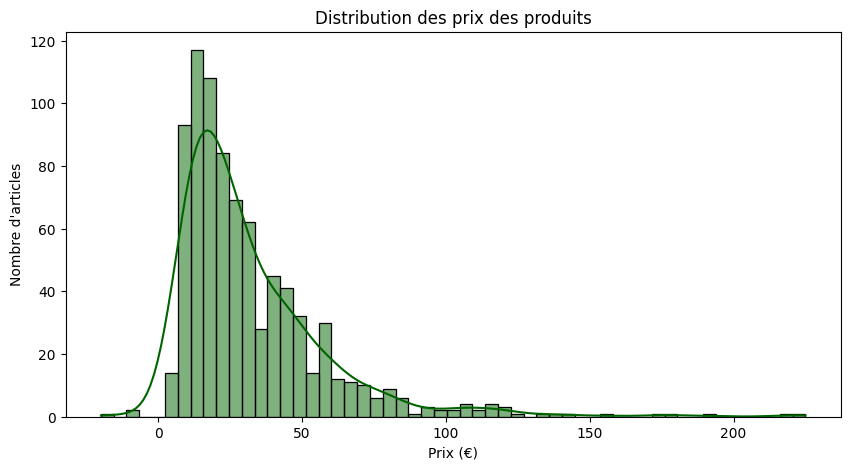

In [ ]:
#Importation des bibliothèques nécessaires pour la visualisation des données
import seaborn as sns #Seaborn pour créer des visualisations plus avancées et esthétiques
import matplotlib.pyplot as plt #Matplotlib pour la gestion des graphiques

#Définir la taille de la figure (largeur = 10, hauteur = 5)
plt.figure(figsize=(10, 5))

#Créer un histogramme de la distribution des prix avec 50 intervalles (bins)
sns.histplot(df_final['price'], #Utiliser la colonne "price" pour l'analyse
             bins=55, #Définir le nombre d'intervalles pour regrouper les prix
             kde=True, #Ajouter une courbe de densité pour mieux voir la distribution
             color="DarkGreen") #Définir la couleur de l'histogramme

plt.title("Distribution des prix des produits") #Ajouter un titre au graphique
plt.xlabel("Prix (€)") #Ajouter un label pour l'axe X (les prix en €)
plt.ylabel("Nombre d'articles") #Ajouter un label pour l'axe Y (le nombre d'articles)
plt.show() #Afficher le graphique


### 📌 Cet histogramme montre la distribution des prix des produits de base et permet de comprendre quels produits peuvent être considérés comme aberrants.

✅ **Asymétrie à droite.** La plupart des produits ont un prix faible ou moyen (jusqu'à ≈ 50€). Plus le prix est élevé, plus les produits sont rares. La courbe KDE montre une diminution progressive de la fréquence des produits chers.

✅ **Pas de rupture nette.** La diminution de la fréquence des produits coûteux est graduelle. Il n'y a pas d'écart important dans les données après un certain seuil de prix.

✅ **Quelques produits au prix très élevé (> 150€).** Ils sont très peu nombreux, mais ils existent. Il s'agit probablement d'articles premium plutôt que d'erreurs. En d'autres termes, les produits dont le prix est élevé (100€ - 225€) ne sont PAS des valeurs aberrantes évidentes. La fréquence diminuant progressivement, il pourrait s'agir d'une distribution naturelle (segment onéreux).

✅ **Il y a des articles avec un prix négatif.** Il s'agit d'une erreur dans les données, car les prix ne peuvent pas être négatifs. Ces lignes doivent être vérifiées et corrigées.

In [ ]:
# Analyse par catégorie
# groupby('product_type') : regroupe les données par la colonne 'product_type' (type de produit)
# ['price'] : sélectionne uniquement la colonne 'price' pour l'analyse statistique
# .describe() : fournit des statistiques descriptives sur les prix de chaque catégorie
df_final.groupby('product_type')['price'].describe()

,count,mean,std,min,25%,50%,75%,max
product_type,,,,,,,,
Champagne,28.0,69.626786,47.621631,12.65,39.000,56.00,80.375,225.0
Cognac,8.0,97.500000,48.153208,44.00,61.850,86.05,120.625,176.0
Gin,2.0,36.000000,0.000000,36.00,36.000,36.00,36.000,36.0
Huile d'olive,3.0,24.933333,15.291937,13.10,16.300,19.50,30.850,42.2
Vin,658.0,29.281307,23.456566,5.20,13.500,21.85,38.400,217.5
Whisky,14.0,65.557143,26.060129,27.50,51.375,59.00,61.450,122.0


### 📌 Y a-t-il des erreurs de prix ?

✅ Cognac, Champagne et Whisky ont des prix élevés, mais ces catégories justifient ces valeurs. Ce ne sont pas des anomalies.

✅ Le vin a une large gamme de prix (max = 217.5€), donc il faut vérifier s'il s'agit de vins haut de gamme.

✅ Aucune erreur visible pour les autres catégories.

<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 5 - Analyse univarié du CA, des quantités vendues, des stocks et de la marge ainsi qu'une analyse multivarié  </h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.1 - Analyse des ventes en CA</h3>
</div>

L'analyse univariée est l'étude d'une seule variable, en l'occurrence le chiffre d'affaires (CA), sans tenir compte de l'influence d'autres facteurs.

**Les principaux objectifs de l'analyse sont les suivants :**
*   Évaluer la distribution des recettes par produit (par exemple, moyenne, médiane, fourchette de valeurs)
*   Identifier les anomalies (revenus très élevés ou très faibles)
*   Identifier les produits les plus rentables

**Quelles sont les mesures utilisées ?**
*   Revenu moyen et médian
*   Écart-type pour comprendre l'ampleur de la différence entre les valeurs et la moyenne
*   Histogramme de distribution pour visualiser la variation des revenus par produit
*   Recherche des valeurs aberrantes (par exemple, les éléments dont le revenu est extrêmement élevé ou faible)

In [ ]:
##############################
# Calculer le CA su site web #
##############################

#Créez une colonne calculant le CA par article :
#une colonne "ca_par_article" qui calcule le CA pour chaque article
#CA = prix * quantité vendue
df_final['ca_par_article'] = df_final['price'] * df_final['total_sales']

#Calculez la somme de la colonne "ca_par_article" - pour obtenir le chiffre d'affaires global du site web
chiffre_affaires_total = df_final['ca_par_article'].sum()

#Ce résultat correspond au chiffre d'affaire du site web
print(f" Chiffre d'affaires total du site web : {chiffre_affaires_total:.2f} €")

 Chiffre d'affaires total du site web : 143680.10 €


In [ ]:
###############################
# Palmares des articles en CA #
###############################

#Effectuer le tri dans l'ordre décroissant du CA du dataset
df_top_ca = df_final.sort_values(by='ca_par_article', ascending=False)

#Supprimer les doublons pour obtenir 20 valeurs uniques de "post_title"
df_top_ca = df_top_ca.drop_duplicates(subset=['post_title'])

#Réinitialiser l'index du dataset par un reset_index
df_top_ca = df_top_ca.reset_index(drop=True)

#Afficher les 20 premier articles en CA
print(" Top 20 des articles par chiffre d'affaires :")
print(df_top_ca[['post_title', 'ca_par_article']].head(20))

 Top 20 des articles par chiffre d'affaires :
                                           post_title  ca_par_article
0      Champagne Egly-Ouriet Grand Cru Millésimé 2008          2475.0
1   Coteaux Champenois Egly-Ouriet Ambonnay Rouge ...          1147.8
2           Champagne Egly-Ouriet Grand Cru Brut Rosé          1113.0
3               Agnès Levet Côte Rôtie Améthyste 2017           824.0
4   Domaine des Comtes Lafon Volnay 1er Cru Santen...           805.0
5   Champagne Agrapart &amp; Fils Minéral Extra Br...           781.2
6   Domaine des Comtes Lafon Volnay 1er Cru Santen...           735.0
7                 Camille Giroud Clos de Vougeot 2016           700.0
8              Champagne Gosset Célébris Vintage 2007           675.0
9   Champagne Agrapart &amp; Fils L'Avizoise Extra...           672.0
10  David Duband Chambolle-Musigny 1er Cru Les Sen...           633.6
11  Cognac Frapin Château de Fontpinot 1989 20 Ans...           628.0
12  Bernard Baudry Chinon Rouge La Croix Boi

*   Le Champagne Egly-Ouriet Grand Cru Millésimé 2008, avec un chiffre d'affaires de 2 475,0 €, est le plus gros contributeur au chiffre d'affaires - le leader des ventes est le Champagne Egly-Ouriet Grand Cru Millésimé 2008.

*   Les vins et champagnes chers dominent - le top 20 est principalement composé de vins, champagnes et cognacs haut de gamme, ce qui indique la contribution significative du segment haut de gamme au chiffre d'affaires total.

*   Répartition de la valeur - une différence significative entre la première place (2 475,0 €) et la vingtième place (582,0 €), soulignant la concentration du chiffre d'affaires sur quelques produits clés.

*   Catégories populaires - le champagne, les vins rouges de Bourgogne, le cognac et les Côtes de Roti sont fréquents, ce qui indique une forte demande pour les boissons françaises haut de gamme.

In [ ]:
import plotly.express as px

# Créer un graphique en barres sans valeurs numériques fixes sur chaque barre
fig = px.bar(
    df_top_ca.head(20),  #Sélectionner les 20 premiers articles uniques
    x='post_title',  #Axe X : noms des produits
    y='ca_par_article',  #Axe Y : chiffre d'affaires généré
    title="Top 20 des articles par chiffre d'affaires",  #Titre du graphique
    labels={'post_title': 'Articles', 'ca_par_article': "Chiffre d'Affaires (€)"},  #Libellés des axes
    color='ca_par_article',  #Couleur basée sur le CA
    color_continuous_scale=["#FFD700", "#008000"]  #Dégradé de jaune (très clair) à vert foncé
)
fig.update_layout(
    xaxis={'categoryorder': 'total descending'},  #Trier les articles de gauche à droite
    xaxis_tickangle=-45,  #Incliner les étiquettes des produits pour améliorer la lisibilité
    height=800, width=1100,  #Ajuster la taille pour une meilleure visibilité
    template='plotly_white'  #Style visuel du graphique
)

#Afficher le graphique interactif
fig.show()

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.2 - Analyse des ventes en Quantités</h3>
</div>

In [ ]:
#####################################
# Palmares des articles en quantité #
#####################################

#Effectuer le tri dans l'ordre décroissant de quantités vendues du dataset df_merge
df_top_quantite = df_final.sort_values(by='total_sales', ascending=False)

#Supprimer les doublons pour obtenir 20 valeurs uniques de "post_title"
df_top_quantite = df_top_quantite.drop_duplicates(subset=['post_title'])

#Réinitialiser l'index du dataset par un reset_index
df_top_quantite = df_top_quantite.reset_index(drop=True)

#Afficher les 20 premier articles en quantité
print("Top 20 des articles par quantités vendues :")
print(df_top_quantite[['post_title', 'total_sales']].head(20))

Top 20 des articles par quantités vendues :
                                           post_title  total_sales
0   Château De La Selve IGP Coteaux de l'Ardèche M...         36.0
1   Mas Laval IGP Pays d'Hérault Les Pampres Blanc...         27.0
2               I Fabbri Chianti Classico Lamole 2017         24.0
3            François Baur Pinot Noir Schlittweg 2017         22.0
4   Bernard Baudry Chinon Rouge La Croix Boissée 2017         22.0
5               Agnès Levet Côte Rôtie Améthyste 2017         20.0
6   Moulin de Gassac IGP Pays d'Hérault Guilhem Bl...         20.0
7   Xavier Frissant Touraine Amboise Chenin Les Pi...         18.0
8                Château Tour Haut-Caussan Médoc 2015         17.0
9                Decelle-Villa Chorey-Lès-Beaune 2016         17.0
10                       Maurel Pays d'Oc Merlot 2018         17.0
11    Philippe Nusswitz IGP Cévènnes Rosé O Pale 2019         16.0
12           Maurel Pays d'Oc Cabernet-Sauvignon 2017         16.0
13  Mourgues du Gr

*   **Le leader des ventes** est le Château De La Selve IGP Coteaux de l'Ardèche, avec 36 unités vendues. Il s'agit d'un best-seller potentiel qui nécessite un contrôle constant des stocks.

*   **Répartition des ventes** - les 20 produits les plus vendus l'ont été entre 36 et 15 unités. Cela indique qu'il n'y a pas de monopole clair et que la demande est répartie entre plusieurs produits.

*   **Catégories de produits** - la liste est représentée par des vins de différentes régions (IGP Pays d'Hérault, Chianti Classico, Côte Rôtie, Médoc, etc.) Cela signifie qu'il existe une demande pour des produits provenant de différentes régions viticoles.

*   **Une variété de segments de prix** - il y a des positions premium (Côte Rôtie Améthyste 2017) ainsi que des vins plus abordables (Pays d'Oc, Costières de Nîmes).

*   **La popularité des vins rosés** - il y a plusieurs positions de vins roses sur la liste (IGP Méditerranée Rosé, Costières de Nîmes Galets Rosés, Château Ollieux Romanis Rosé), confirmant la forte demande pour ce type de boisson.

**CONCLUSION :** ces 20 produits constituent la colonne vertébrale des ventes et leurs stocks doivent être surveillés de près. Il est possible d'étudier leurs caractéristiques communes (catégories, régions, segments de prix) et de s'en servir pour promouvoir des produits similaires. Il est intéressant d'étudier les marges - il se peut que tous ces produits ne maximisent pas les bénéfices.

In [ ]:
#Graphique en barre des 20 premiers articles avec plotly express
fig = px.bar(
    df_top_quantite.head(20),  # Sélectionner les 20 premiers articles uniques
    x='post_title',  # Axe X : noms des produits
    y='total_sales',  # Axe Y : quantités vendues
    title="Top 20 des articles par quantités vendues",  # Titre du graphique
    labels={'post_title': 'Articles', 'total_sales': "Quantités vendues"},  # Libellés des axes
    color='total_sales',  # Couleur basée sur la quantité vendue
    color_continuous_scale=["#FFD700", "#008000"]  # Dégradé de jaune (très clair) à vert foncé
)

fig.update_layout(
    xaxis={'categoryorder': 'total descending'},  # Trier les articles de gauche à droite
    xaxis_tickangle=-45,  # Incliner les étiquettes des produits pour améliorer la lisibilité
    height=800, width=1100,  # Ajuster la taille pour une meilleure visibilité
    template='plotly_white'  # Style visuel du graphique
)

# Afficher le graphique interactif
fig.show()

In [ ]:
#############################
# Calculer le 20 / 80 en CA #
#############################

#Créer une colonne calculant la part en quantité de la ligne dans le dataset
df_final['part_quantite'] = df_final['total_sales'] / df_final['total_sales'].sum()

#Créer une colonne réalisant la somme cumulative de la colonne précedemment créée
df_final = df_final.sort_values(by='part_quantite', ascending=False)  # Trier par ordre décroissant
df_final['quantite_cumulee'] = df_final['part_quantite'].cumsum()

#Grâce au deux colonnes créées précedemment, calculer le nombre d'articles représentant 80% des ventes en quantité
nombre_articles_80 = (df_final['quantite_cumulee'] <= 0.8).sum()

#Afficher la proportion que représentent ce groupe d'articles dans le catalogue entier du site web
proportion_articles = (nombre_articles_80 / df_final.shape[0]) * 100
print(f"Nombre d'articles représentant 80% des ventes en quantité : {nombre_articles_80}")
print(f"Proportion de ces articles dans le catalogue total : {proportion_articles:.0f} %")

Nombre d'articles représentant 80% des ventes en quantité : 433
Proportion de ces articles dans le catalogue total : 52 %


*   433 produits représentent 80% des ventes en quantité. Ces produits représentent 52% de l'ensemble du catalogue. Cela signifie qu'un peu plus de la moitié de l'assortiment (52 %) constitue l'essentiel des ventes.

*   Les 48 % de produits restants sont vendus rarement ou en petites quantités.

**CONCLUSION :** il est possible de se concentrer sur ces 433 produits : contrôler leur stock (car ils fournissent le revenu principal), optimiser l'assortiment (revoir les produits peu vendus) et renforcer le marketing pour ce groupe de produits clés.

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.3 - Analyse des stocks</h3>
</div>

In [ ]:
######################################
# Calcule le nombre de mois de stock #
######################################

# Import de numpy
import numpy as np
import plotly.express as px

# Création de la colonne Rotation de stock (nombre de mois de stock)
# Nombre de mois de stock = stock_quantity / (total_sales / 12) (en supposant une répartition uniforme des ventes sur l'année)
df_final.loc[:, 'mois_stock'] = np.where(df_final['total_sales'] > 0,
                                         df_final['stock_quantity'] / (df_final['total_sales'] / 12),
                                         np.inf)  # Si total_sales = 0, mettre "inf" (stock non écoulé)

# Remplacement des valeurs infinies par 0 (éviter les erreurs dans l'analyse)
df_final['mois_stock'] = df_final['mois_stock'].replace([np.inf, -np.inf], 0)

# Effectuer le tri dans l'ordre décroissant du nombre de mois de stock dans le dataset df_final
df_stock_sorted = df_final.sort_values(by='mois_stock', ascending=False)

# Sélection des 20 produits avec le plus de mois de stock
df_top_stock = df_stock_sorted.head(20)

# Graphique en barre du flop 20 des produits qui ont le plus de mois de stock
fig = px.bar(
    df_top_stock,
    x='post_title',
    y='mois_stock',
    title="Flop 20 des produits avec le plus de mois de stock",
    labels={'post_title': 'Articles', 'mois_stock': "Mois de stock"},
    color='mois_stock',
    color_continuous_scale=["#FFD700", "#008000"]
)

# Personnalisation du graphique
fig.update_layout(
    xaxis={'categoryorder': 'total descending'},
    xaxis_tickangle=-45,
    height=800, width=1100,
    template='plotly_white'
)

# Afficher le graphique interactif
fig.show()

In [ ]:
####################################
# Valorisation des stocks en euros #
####################################

#Création de la colonne Valorisation des stocks en euros
df_final['Valorisation_stock_euros'] = df_final['stock_quantity'] * df_final['price']

#Calculer la somme de la colonne "Valorisation_stock_euros"
valorisation_totale = df_final['Valorisation_stock_euros'].sum()
print(f"Valorisation totale des stocks en euros : {valorisation_totale:.2f} €")

Valorisation totale des stocks en euros : 531628.80 €


In [ ]:
##############################################
# Valorisation du nombre de produit en stock #
##############################################

#Calculer la somme de la colonne stock quantity
total_stock_quantity = df_final['stock_quantity'].sum()

# Afficher le résultat
print(f"Nombre total de produits en stock : {total_stock_quantity}")

Nombre total de produits en stock : 17811


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.4 - Analyse du taux de marge</h3>
</div>

In [ ]:
############################
# Analyse du taux de marge #
############################

#Création de la colonne prix HT
# Supposons que la TVA soit de 20% (ajuster si nécessaire)
df_final['prix_HT'] = df_final['price'] / 1.2

#Création de la colonne Taux de marge
# Calcul du taux de marge : ((prix de vente - prix d'achat) / prix d'achat) * 100
df_final['taux_marge'] = ((df_final['price'] - df_final['purchase_price']) / df_final['purchase_price']) * 100

#Afficher le prix minimum de la colonne "taux_marge"
taux_marge_min = df_final['taux_marge'].min()
print(f"Taux de marge minimum : {taux_marge_min:.2f} %")

#Afficher le prix maximum de la colonne "taux_marge"
taux_marge_max = df_final['taux_marge'].max()
print(f"Taux de marge maximum : {taux_marge_max:.2f} %")

Taux de marge minimum : -297.40 %
Taux de marge maximum : 129.69 %


Taux de marge minimum : -297.40 %
*   Un taux de marge négatif signifie que le prix de vente (price) est inférieur au prix d'achat (purchase_price).
*   Dans ce cas, -297,40 % est une très forte diminution du prix, ce qui peut indiquer : Une erreur de données (prix d'achat ou prix de vente incorrect),  Une promotion ou une démarque à perte (vente à perte), Un problème de calcul (par exemple, des taux de TVA incorrects).

Taux de marge maximum : 129.69%
*   Une valeur positive de 129,69% signifie que le produit est vendu plus de 2 fois son prix d'achat.
*   Cela peut être normal pour des produits haut de gamme (vins rares, cognacs exclusifs, etc.).
Il convient toutefois de vérifier s'il n'y a pas d'erreurs dans les données (prix d'achat gonflé ou prix de vente faible).

In [ ]:
#affichage de la ligne avec un taux de marge inférieur à 0
produits_perte = df_final[df_final['taux_marge'] < 0]
print(produits_perte[['post_title', 'price', 'purchase_price', 'taux_marge']])

                                         post_title  price  purchase_price  \
210  Champagne Egly-Ouriet Grand Cru Blanc de Noirs  12.65           77.48   
151                                             NaN -20.00           10.33   
391                                             NaN   8.30            9.99   
469                                             NaN  -8.00            4.34   
724                                             NaN  92.00           99.00   
739                                             NaN  -9.10            4.61   
817                                             NaN  31.00           31.20   

     taux_marge  
210  -83.673206  
151 -293.610842  
391  -16.916917  
469 -284.331797  
724   -7.070707  
739 -297.396963  
817   -0.641026  


Explication du résultat :

*   Les articles dont le prix est inférieur à 0 sont des erreurs évidentes dans les données. Vous devez remplacer les prix négatifs par NaN ou 0, ou spécifier les valeurs correctes dans la base de données.

*   Le Champagne Egly-Ouriet Grand Cru Blanc de Noirs se vend 12,65 €, alors que son prix d'achat est de 77,48 €. Il s'agit soit d'une erreur de prix, soit d'une remise sur le produit. Vous devez vérifier s'il y a une erreur de prix ou de prix d'achat. Ou vérifier si la remise a été appliquée.

*   La marge presque nulle (-0,64 %) indique que le produit est vendu avec un bénéfice presque nul. Il peut être intéressant de reconsidérer le prix de ce produit.

In [ ]:
#création d'un dataframe avec les taux positifs
produits_marge_positive = df_final[df_final['taux_marge'] > 0]

#Afficher le prix minimum de la colonne "taux_marge"
taux_marge_min = produits_marge_positive['taux_marge'].min()
print(f"Taux de marge positif minimum : {taux_marge_min:.2f} %")

#Afficher le prix maximum de la colonne "taux_marge"
taux_marge_max = produits_marge_positive['taux_marge'].max()
print(f"Taux de marge positif maximum : {taux_marge_max:.2f} %")

Taux de marge positif minimum : 55.40 %
Taux de marge positif maximum : 129.69 %


**Explication du résultat** : Le pourcentage de profit le plus faible parmi les produits rentables est de 55,4 % du prix de revient et, pour le produit le plus rentable, la marge est presque 2,3 fois supérieure au prix de revient.

In [ ]:
#création d'un dataframe avec le taux de marge moyen par type de produit
df_marge_moyenne = df_final.groupby('product_type', as_index=False)['taux_marge'].mean()

# Trier le dataframe par taux de marge moyen en ordre décroissant
df_marge_moyenne = df_marge_moyenne.sort_values(by='taux_marge', ascending=False)

# Affichage du dataframe
print(df_marge_moyenne)

    product_type  taux_marge
1         Cognac  118.779435
5         Whisky  118.087005
2            Gin  109.790210
4            Vin   93.795313
0      Champagne   62.530589
3  Huile d'olive   60.068162


**Cette analyse montre le taux de marge moyen par catégorie de produits.**

*    Le Cognac (118,78%) et le Whisky (118,08%) ont les marges les plus élevées. Ces catégories de produits sont vendues à un taux de marge élevé (près de 2,2 fois leur prix d'achat). Cela s'explique par leur caractère haut de gamme, leur vieillissement et leur exclusivité.

*   Le gin (109,79 %) présente également une marge élevée. Cela peut être attribué à son positionnement en tant qu'alcool d'auteur à forte valeur ajoutée.
Le vin (93,79 %) a une marge modérée mais élevée. Les vins ont des niveaux de prix différents, mais sont vendus en moyenne près de deux fois le prix de revient.

*   Le champagne (62,53 %) et l'huile d'olive (60,07 %) ont les marges les plus faibles. Le champagne nécessite traditionnellement une production coûteuse, mais la concurrence limite la marge. L'huile d'olive a la marge la plus faible car il s'agit d'un produit de consommation courante et des prix gonflés peuvent réduire la demande.

*Cette analyse permet de comprendre quelles sont les catégories les plus rentables et où les prix peuvent être optimisés.*

In [ ]:
#Affichage dans un graphique du taux de marge par type de produit
import plotly.express as px

# Création d'un graphique en barres pour le taux de marge moyen par type de produit
fig = px.bar(
    df_marge_moyenne,  # Dataframe contenant les moyennes
    x='product_type',  # Axe X : types de produits
    y='taux_marge',  # Axe Y : taux de marge moyen
    title="Taux de marge moyen par type de produit",  # Titre du graphique
    labels={'product_type': 'Type de produit', 'taux_marge': 'Taux de marge (%)'},  # Libellés des axes
    color='taux_marge',  # Couleur basée sur la valeur du taux de marge
    color_continuous_scale=["#FFD700", "#008000"]  # Palette de couleurs
)

# Personnalisation du graphique
fig.update_layout(
    xaxis_tickangle=-45,  # Incliner les étiquettes de l'axe X pour une meilleure lisibilité
    template='plotly_white',  # Style visuel du graphique
    height=600, width=900  # Ajustement de la taille du graphique
)

fig.update_traces(texttemplate='%{y:.2f}', textposition='outside')

# Affichage du graphique interactif
fig.show()

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.5 - Analyse des correlations entre les variables stock, sales et price</h3>
</div>

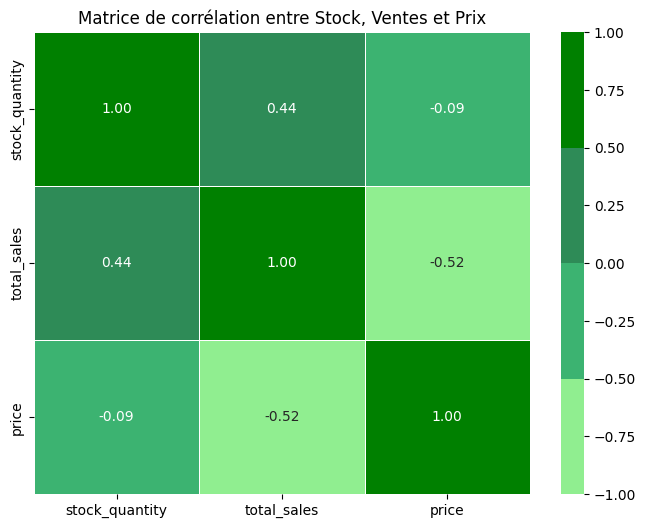

In [ ]:
############################
# Analyse des correlations #
############################

#Importation de Seaborn
import seaborn as sns
import matplotlib.pyplot as plt

#Création d'un heatmap de correlation avec les variables stock, sales et price
df_corr = df_final[['stock_quantity', 'total_sales', 'price']] #Sélection des variables d'intérêt

#Calcul de la matrice de corrélation
correlation_matrix = df_corr.corr()

#Création de la heatmap avec Seaborn
plt.figure(figsize=(8, 6))  # Définir la taille du graphique
sns.heatmap(correlation_matrix,
            annot=True, # Ajout de valeurs numériques au graphique
            cmap=sns.color_palette(["lightgreen", "MediumSeaGreen", "SeaGreen", "green"], as_cmap=True), # Palette de couleurs
            fmt=".2f", # Arrondir les valeurs à deux chiffres
            linewidths=0.5,  # Largeur de la bordure de la cellule
            vmin=-1, vmax=1) # Échelle de corrélation (-1 à 1)

#Personnalisation du graphique
plt.title("Matrice de corrélation entre Stock, Ventes et Prix")  # Ajouter un titre

#Affichage du graphique
plt.show()

In [ ]:
#Que peut-on conclure des correlations ?

**Explication des résultats du graphique :**

1. **Corrélation entre la quantité de stock et le total des ventes** → 0,44 (modérément positif).

**Principale conclusion :** les stocks et les ventes ont une relation modérément positive.

**Explication :** cela signifie qu'une augmentation des stocks de marchandises contribue en partie à une augmentation des ventes. Cependant, le coefficient de 0,44 indique que cette relation n'est pas absolue - d'autres facteurs (par exemple, le prix, la saisonnalité, la popularité du produit) affectent également les ventes.

2. **Corrélation entre le prix et le chiffre d'affaires total** → -0,52 (négatif modérément fort).

**Principale conclusion :** plus le prix est élevé, plus les ventes sont faibles.

**Explication :** une corrélation négative de -0,52 indique une relation inverse assez forte - les produits chers se vendent moins bien et les produits plus abordables se vendent mieux. Il s'agit d'une situation typique pour la plupart des marchés : les clients préfèrent les articles plus abordables et seule une petite fraction d'entre eux choisit les articles coûteux.

3. **Corrélation entre le prix et la quantité de stock** → -0,09 (négatif très faible).

**Principale conclusion :** les stocks sont presque indépendants du prix.

**Explication :** la corrélation de -0,09 est presque nulle, ce qui indique qu'il n'y a pratiquement aucune relation entre le prix d'un produit et sa quantité en stock. Cela signifie que des produits dont le prix est élevé ou bas peuvent avoir des stocks importants ou faibles - les stocks ne sont pas constitués en fonction du prix, mais d'autres critères (par exemple, la demande, la saisonnalité, les politiques d'achat).


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.6 - Mettre à disposition la nouvelle table sur un fichier Excel</h3>
</div>

In [ ]:
#Mettre le dataset df_merge sur un fichier Excel
#Supprimer les index (index=False) afin qu'ils ne soient pas stockés dans le fichier
df_merge.to_excel("df_merge.xlsx", index=False)

#Afficher la confirmation
print("Le fichier 'df_merge.xlsx' a été enregistré avec succès.")

Le fichier 'df_merge.xlsx' a été enregistré avec succès.
